# Fixed Graphs
All embedded captions/footnotes removed. Colors corrected. Titles made descriptive.
**Put explanatory text in your LaTeX `\caption{}`, not inside the figure.**

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Shared palette
C_GREY_LIGHT = '#B0B8C1'   # babysitting teacher
C_GREY_MID   = '#6B7785'   # babysitting student
C_BLUE       = '#4292C6'   # our teacher
C_NAVY       = '#08306B'   # our student
C_GREY_BAR   = '#9EAAB5'   # neutral grey for zero-result bar
C_RED_LINE   = '#C0392B'   # reference lines
C_GREEN_LIGHT = "#2C9C03"  # light green for success indicators
C_GREEN_LIME  = "#18BB3E"  # lime green for success indicators
C_GREEN_FOREST = "#0B6E3A"  # forest green for success indicators
C_GREEN_DARK  = "#0B3A0D"  # dark green for success indicators
C_RED        = "#C0392B"  # red for error indicators
C_RED_LIGHT = "#F1948A"  # light red for error indicators
C_RED_DARK  = "#A50000"  # dark red for error indicators
C_RED_CORAL = "#FF6F61"  # coral red for error indicators
C_RED_BURGUNDY = "#800020"  # burgundy red for error indicators
C_RED_CRIMSON = "#DC143C"  # crimson red for error indicators
orange_vivid="#FD8D3C"
orange_dark="#D94801"
blue_medium="#3182BD"
blue_dark="#08519C"

## Graph 1 — Distilled student performance

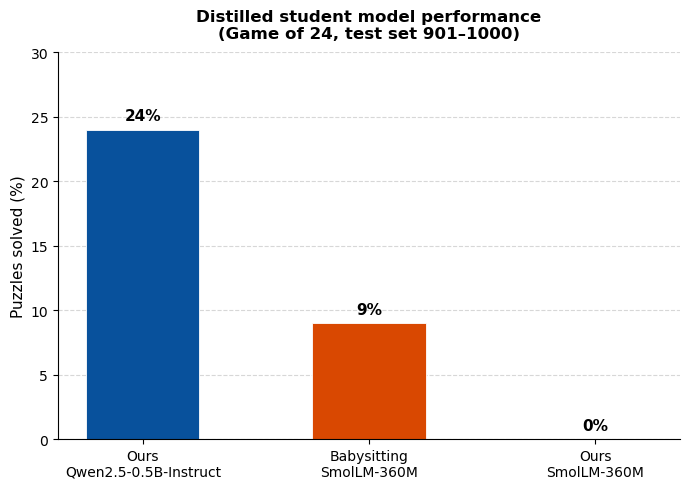

In [51]:
fig, ax = plt.subplots(figsize=(7, 5))

categories = ["Ours\nQwen2.5-0.5B-Instruct", "Babysitting\nSmolLM-360M", "Ours\nSmolLM-360M"]
values     = [24, 9, 0]
colors     = [blue_dark, orange_dark, C_GREY_BAR]  # grey for 0%, not red

bars = ax.bar(categories, values, color=colors, edgecolor='white', linewidth=0.6, width=0.5)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, f'{h}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 30)
ax.set_ylabel('Puzzles solved (%)', fontsize=11)
ax.set_title('Distilled student model performance\n(Game of 24, test set 901–1000)',
             fontsize=12, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('g1_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g1_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 2 — Evaluation loss curves
> Load your JSON files in the cell below. Approximate values are pre-filled as a fallback.

Loaded real JSON data.


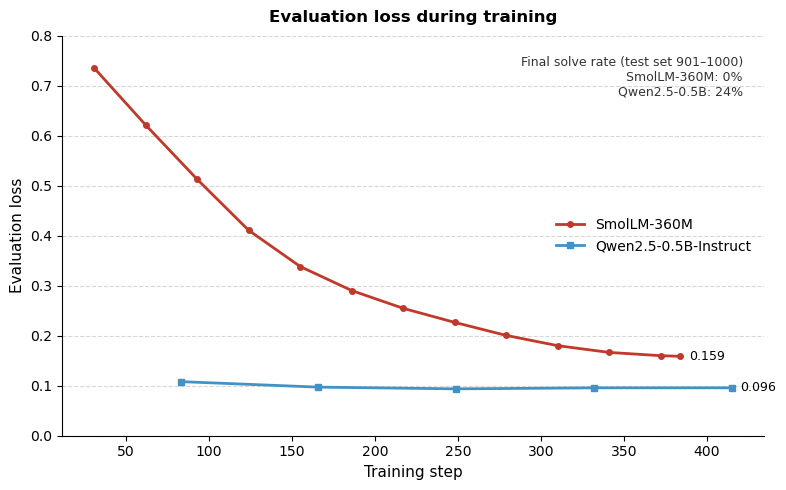

In [52]:
import json

# ── load real data if available ───────────────────────────────────

with open('smollm_training_logs_final.json') as f:
    smollm_data = json.load(f)
smollm_steps = [e['step'] for e in smollm_data if 'eval_loss' in e]
smollm_loss  = [e['eval_loss'] for e in smollm_data if 'eval_loss' in e]

with open('training_logs_qwen05 - try1.json') as f:
    qwen_data = json.load(f)
qwen_steps = [e['step'] for e in qwen_data if 'eval_loss' in e]
qwen_loss  = [e['eval_loss'] for e in qwen_data if 'eval_loss' in e]
print('Loaded real JSON data.')

# except FileNotFoundError:
#     print('JSON files not found — using approximate values from original graph.')
#     smollm_steps = [35,65,85,115,150,170,200,220,250,280,300,330,350,380,390]
#     smollm_loss  = [0.74,0.62,0.51,0.41,0.34,0.29,0.25,0.23,0.23,0.20,0.18,0.17,0.16,0.159,0.159]
#     qwen_steps   = [85,150,200,250,300,350,415]
#     qwen_loss    = [0.110,0.100,0.097,0.096,0.097,0.097,0.096]

# ── plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(smollm_steps, smollm_loss,
        marker='o', markersize=4, linewidth=2,
        color='#C0392B', label='SmolLM-360M')
ax.plot(qwen_steps, qwen_loss,
        marker='s', markersize=4, linewidth=2,
        color=C_BLUE, label='Qwen2.5-0.5B-Instruct')

# endpoint value labels only — no floating box
ax.annotate(f'{smollm_loss[-1]:.3f}',
            xy=(smollm_steps[-1], smollm_loss[-1]),
            xytext=(6, 0), textcoords='offset points', fontsize=9, va='center')
ax.annotate(f'{qwen_loss[-1]:.3f}',
            xy=(qwen_steps[-1], qwen_loss[-1]),
            xytext=(6, 0), textcoords='offset points', fontsize=9, va='center')

# final solve rates as plain text, top-right
ax.text(0.97, 0.95,
        'Final solve rate (test set 901–1000)\nSmolLM-360M: 0%\nQwen2.5-0.5B: 24%',
        transform=ax.transAxes, fontsize=9,
        va='top', ha='right', color='#333333')

ax.set_xlabel('Training step', fontsize=11)
ax.set_ylabel('Evaluation loss', fontsize=11)
ax.set_ylim(0, 0.8)
ax.set_title('Evaluation loss during training', fontsize=12, fontweight='bold', pad=10)
ax.legend(fontsize=10, frameon=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('g2_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g2_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 3 — Training dataset size

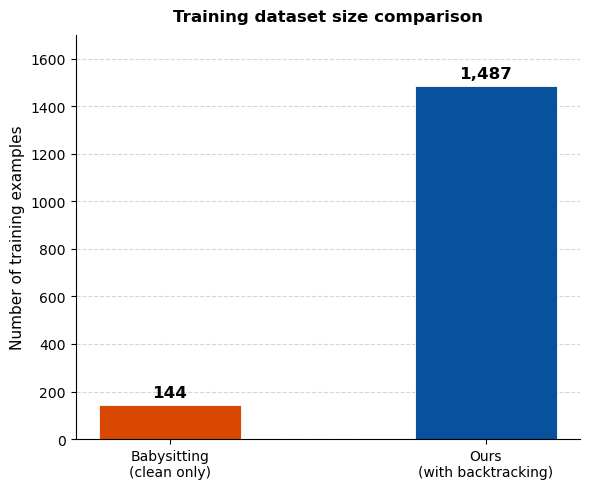

In [53]:
fig, ax = plt.subplots(figsize=(6, 5))

cats   = ['Babysitting\n(clean only)', 'Ours\n(with backtracking)']
vals   = [144, 1487]
colors = [orange_dark, blue_dark]

bars = ax.bar(cats, vals, color=colors, edgecolor='white', linewidth=0.6, width=0.45)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 20, f'{int(h):,}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1700)
ax.set_ylabel('Number of training examples', fontsize=11)
ax.set_title('Training dataset size comparison', fontsize=12, fontweight='bold', pad=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('g3_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g3_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 4 — Teacher → Student performance comparison

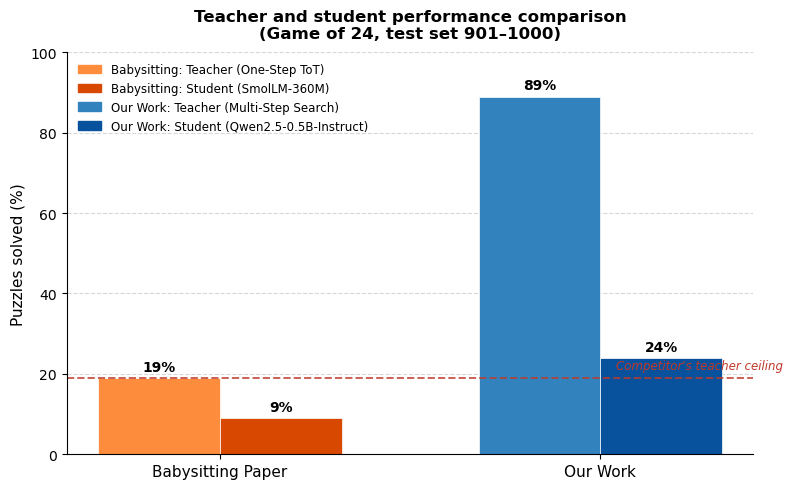

In [54]:
groups = ['Babysitting Paper', 'Our Work']
t_vals = [19, 89]
s_vals = [9,  24]
t_cols = [orange_vivid, blue_medium]
s_cols = [orange_dark,   blue_dark]

x     = np.arange(len(groups))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width/2, t_vals, width, color=t_cols, edgecolor='white', linewidth=0.5)
b2 = ax.bar(x + width/2, s_vals, width, color=s_cols, edgecolor='white', linewidth=0.5)

for bar_set in [b1, b2]:
    for bar in bar_set:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# competitor ceiling reference line
ax.axhline(y=19, color=C_RED_LINE, linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(1.48, 20.5, "Competitor's teacher ceiling",
        ha='right', va='bottom', fontsize=8.5, color=C_RED_LINE, style='italic')

ax.set_ylim(0, 100)
ax.set_ylabel('Puzzles solved (%)', fontsize=11)
ax.set_title('Teacher and student performance comparison\n(Game of 24, test set 901–1000)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color=orange_vivid, label='Babysitting: Teacher (One-Step ToT)'),
    mpatches.Patch(color=orange_dark,   label='Babysitting: Student (SmolLM-360M)'),
    mpatches.Patch(color=blue_medium,       label='Our Work: Teacher (Multi-Step Search)'),
    mpatches.Patch(color=blue_dark,       label='Our Work: Student (Qwen2.5-0.5B-Instruct)'),
]
ax.legend(handles=legend_handles, fontsize=8.5, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('g4_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g4_fixed.png', dpi=300, bbox_inches='tight')
plt.show()


## Graph 5 — Performance relative to CoT baseline
> CoT is shown as a reference line (not a bar) — same value in both groups so a bar adds noise.

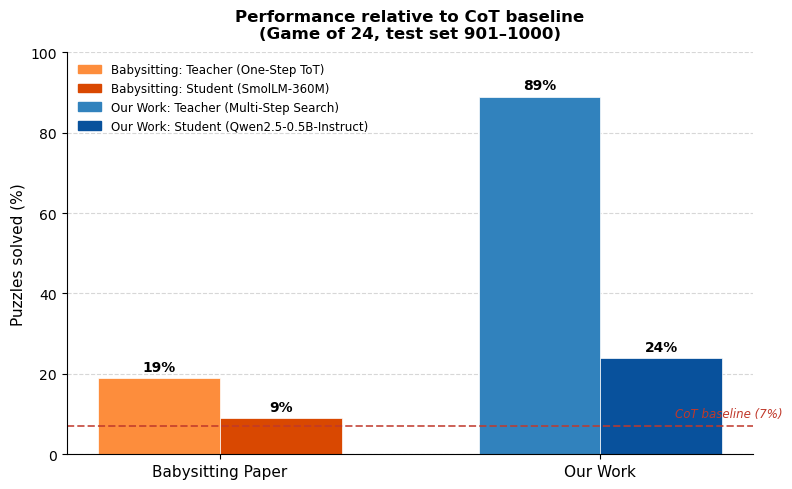

In [55]:
groups = ['Babysitting Paper', 'Our Work']
t_vals = [19, 89]
s_vals = [9,  24]
t_cols = [orange_vivid, blue_medium]
s_cols = [orange_dark,   blue_dark]

x     = np.arange(len(groups))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

b1 = ax.bar(x - width/2, t_vals, width, color=t_cols, edgecolor='white', linewidth=0.5)
b2 = ax.bar(x + width/2, s_vals, width, color=s_cols, edgecolor='white', linewidth=0.5)

for bar_set in [b1, b2]:
    for bar in bar_set:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1, f'{h}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# CoT as reference line — not a bar
ax.axhline(y=7, color=C_RED_LINE, linestyle='--', linewidth=1.4, alpha=0.8)
ax.text(1.48, 8.5, 'CoT baseline (7%)',
        ha='right', va='bottom', fontsize=8.5, color=C_RED_LINE, style='italic')

ax.set_ylim(0, 100)
ax.set_ylabel('Puzzles solved (%)', fontsize=11)
ax.set_title('Performance relative to CoT baseline\n(Game of 24, test set 901–1000)',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color=orange_vivid, label='Babysitting: Teacher (One-Step ToT)'),
    mpatches.Patch(color=orange_dark,   label='Babysitting: Student (SmolLM-360M)'),
    mpatches.Patch(color=blue_medium,       label='Our Work: Teacher (Multi-Step Search)'),
    mpatches.Patch(color=blue_dark,       label='Our Work: Student (Qwen2.5-0.5B-Instruct)'),
]
ax.legend(handles=legend_handles, fontsize=8.5, frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig('g5_fixed.pdf', dpi=300, bbox_inches='tight')
plt.savefig('g5_fixed.png', dpi=300, bbox_inches='tight')
plt.show()
